<a href="https://colab.research.google.com/github/ericrausa1620494/practica-3/blob/main/practica_3_eric_rausa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!setup.py install
!pip install sisl

/bin/bash: line 1: setup.py: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 26.1 MB/s eta 0:00:00


In [2]:
# Code Based on the SISL - SIESTA tutorial
# Create a cube file for HOMO and LUMO to allow visualtization in VMD and other programs
# https://sisl.readthedocs.io/en/latest/tutorials/tutorial_siesta_1.html
# It assumes that you did first the calculation reported in the tutorial

import numpy as np
from sisl import *
import matplotlib.pyplot as plt

#Function integrate
def integrate(g):
    print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))



In [4]:
# -----------------------------
# MAIN CODE
# -----------------------------
# Read Data

#fem que el document llegeixi els imputs de siesta per el c60, i modifiquem el codi usat per al H20

#Read fdf file (input file of SIESTA calculation)
fdf = get_sile('RUN.fdf')
#Read hamiltonian obtained in SISTA calculation
H = fdf.read_hamiltonian()
c60 = H.geometry

#Show results
print("Hamiltonian:")
print(H)

#Eigenstates (NOT ordered)
es = H.eigenstate()

# We specify an origin to center the molecule in the grid
c60.lattice.origin = [-4, -4, -4]

# Reduce the contained eigenstates to only the HOMO and LUMO
# Find the index of the smallest positive eigenvalue
idx_lumo = (es.eig > 0).nonzero()[0][0]
es = es.sub([idx_lumo - 1, idx_lumo])




Hamiltonian:
Hamiltonian{non-zero: 418830, orthogonal: False,
 Spin{unpolarized},
 Geometry{na: 60, no: 780,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01100, maxR: 3.30951,
    AtomicOrbital{2sZ1, q0: 2.0, SphericalOrbital{l: 0, R: 2.6548991702136426, q0: 2.0}},
    AtomicOrbital{2sZ2, q0: 0.0, SphericalOrbital{l: 0, R: 1.6858398488357096, q0: 0.0}},
    AtomicOrbital{2pyZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pzZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pxZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pyZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{2pzZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{2pxZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{3dxyZ1P, q0: 0.0, SphericalOrbital{l

In [5]:
# Ordered eigenstates (show only HOMO LUMO)
print("Ordered Eigenstates")
#print(es)

print("Energies")
print(es.eig)

#Create a grid to project the density
#g = Grid(0.2, sc=h2o.sc)
g = Grid(0.2, lattice=c60.lattice)


Ordered Eigenstates
Energies
[-0.53708672  0.52075157]


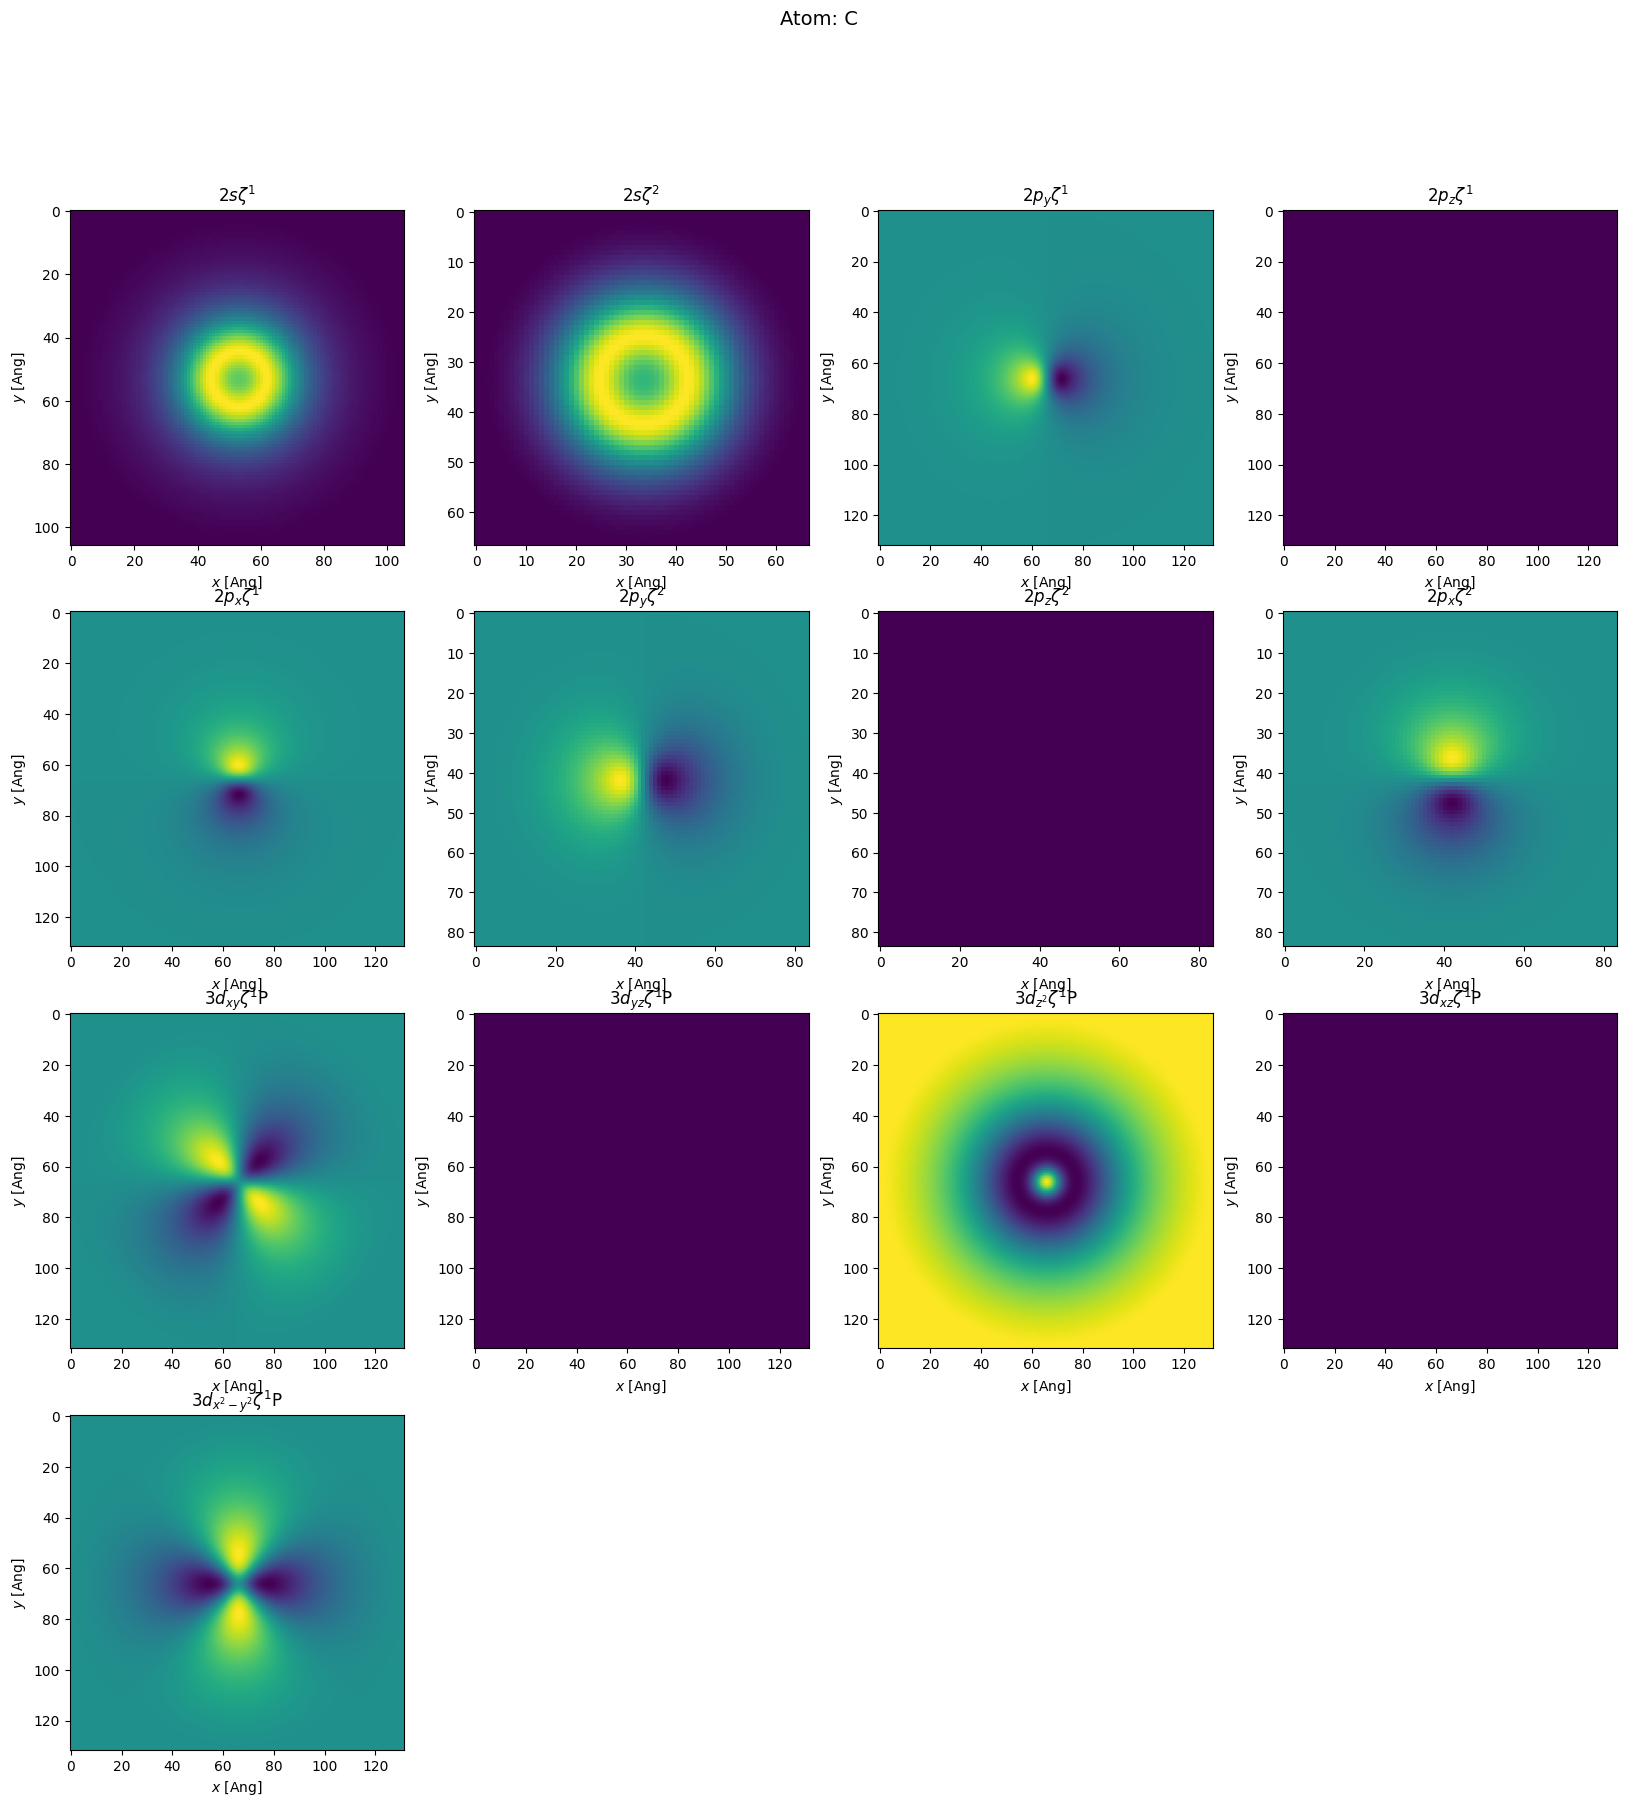

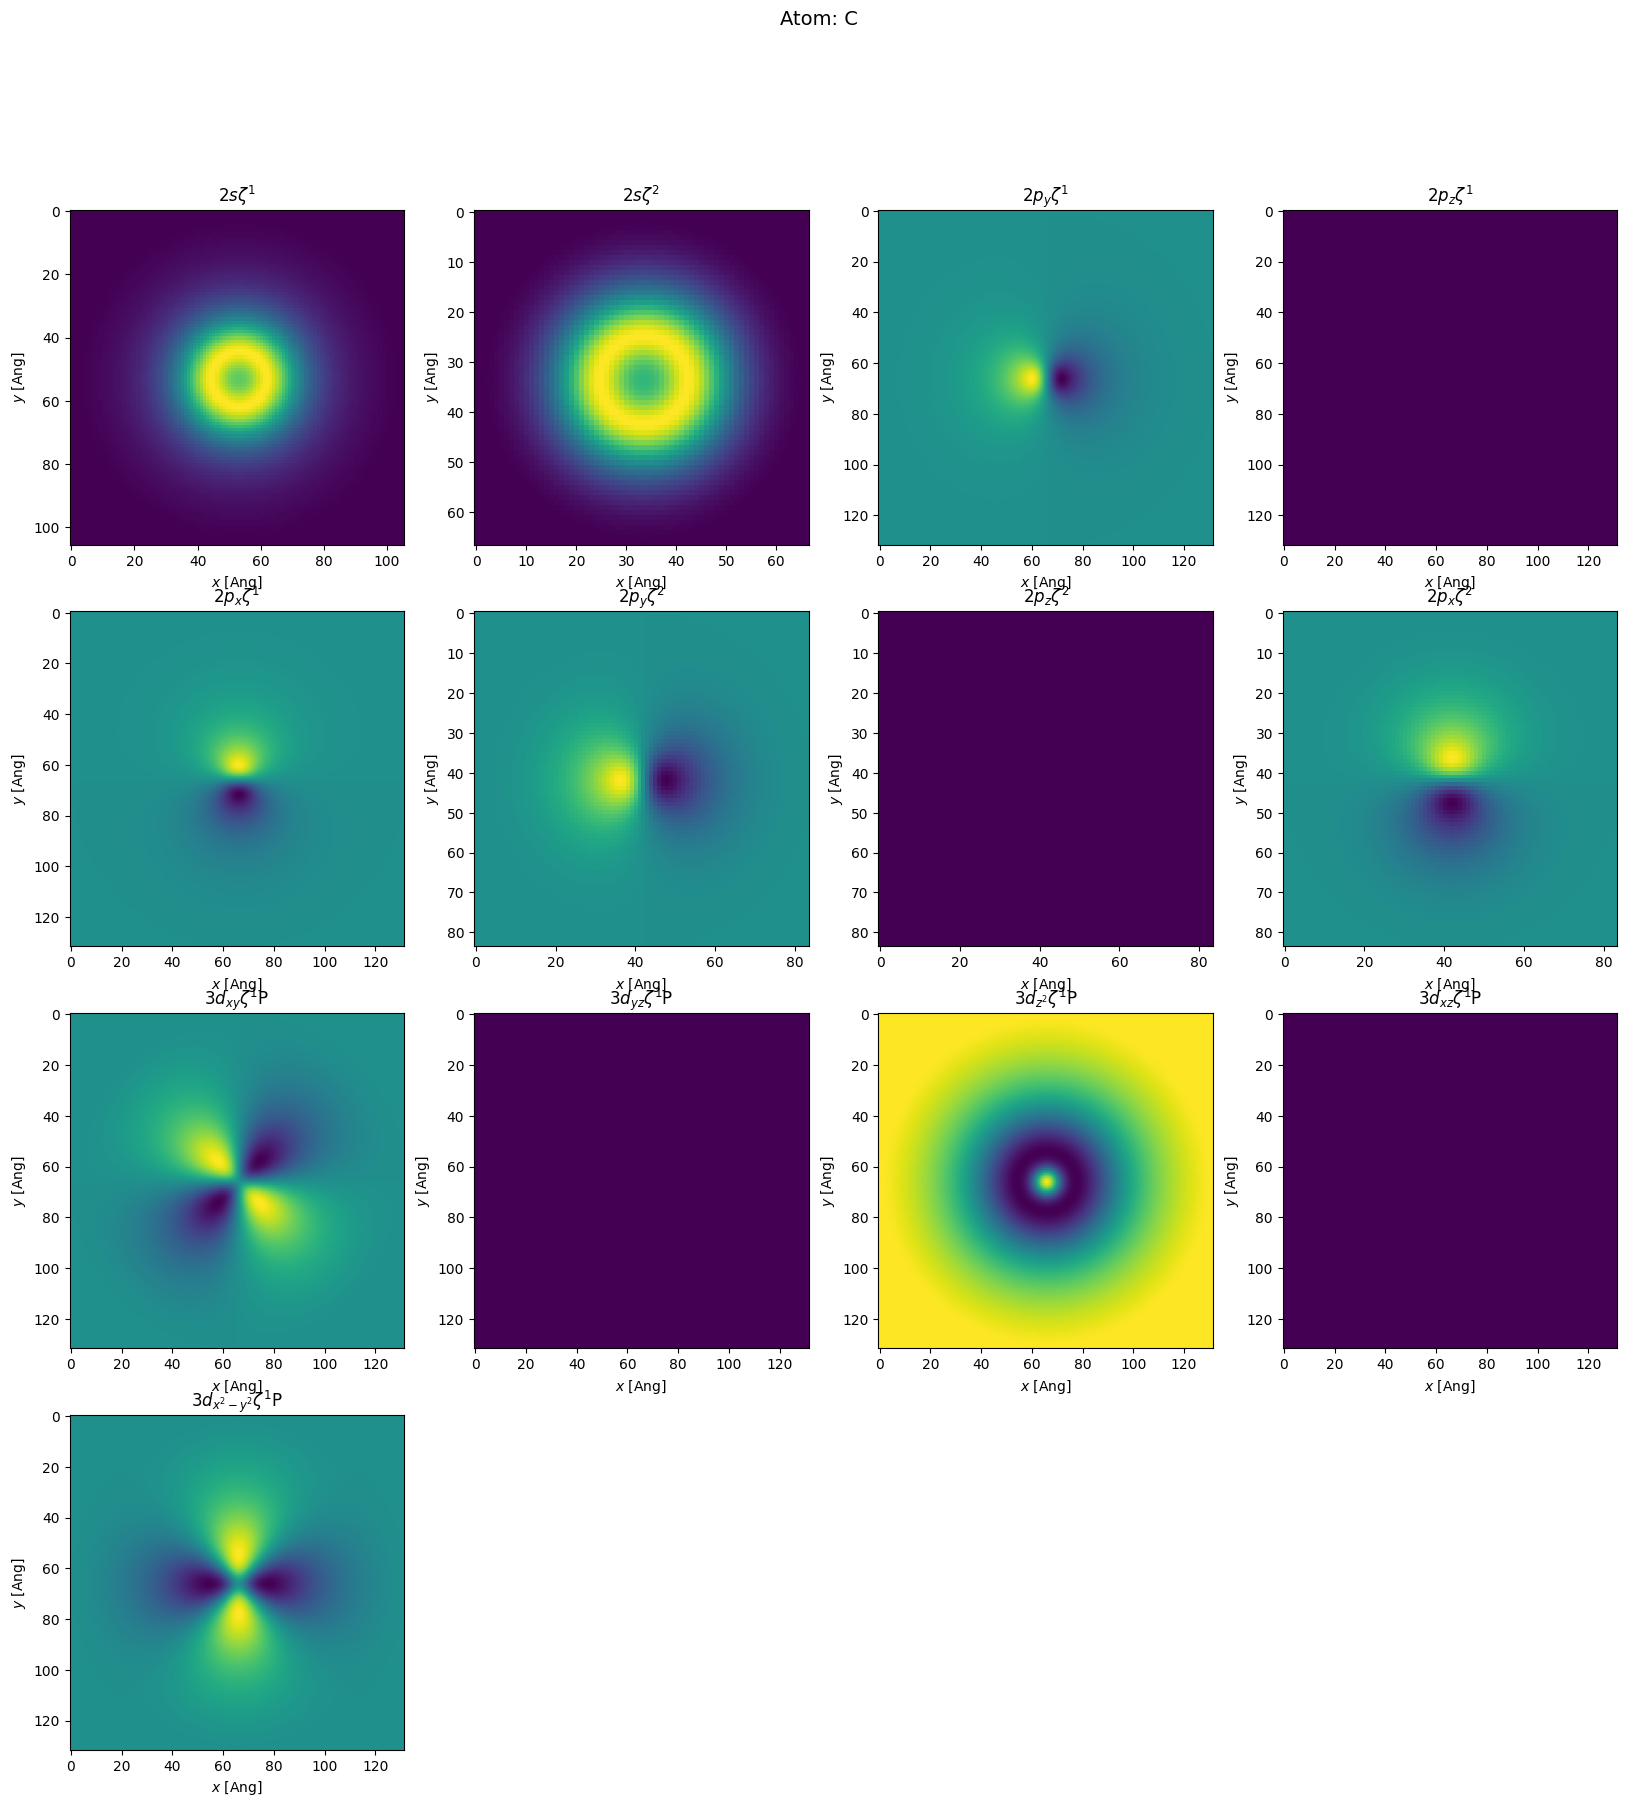

In [6]:
#fem un plot dels orbitals, per veurel's millor en la imatge, modificant el codi del H20

def plot_atom(atom):
    no = len(atom)  # number of orbitals
    nx = no // 4
    ny = no // nx
    if nx * ny < no:
        nx += 1
    fig, axs = plt.subplots(nx, ny, figsize=(20, 5 * nx))
    fig.suptitle("Atom: {}".format(atom.symbol), fontsize=14)

    def my_plot(i, orb):
        grid = orb.toGrid(atom=atom)
        # In case you want to plot it with external software
        # Just uncomment the following line:
        # grid.write("{}_{}.cube".format(atom.symbol, orb.name()))
        c, r = i // 4, (i - 4) % 4
        if nx == 1:
            ax = axs[r]
        else:
            ax = axs[c][r]
        ax.imshow(grid.grid[:, :, grid.shape[2] // 2])
        ax.set_title(r"${}$".format(orb.name(True)))
        ax.set_xlabel(r"$x$ [Ang]")
        ax.set_ylabel(r"$y$ [Ang]")

    i = 0
    for orb in atom:
        my_plot(i, orb)
        i += 1
    if i < nx * ny:
        # This removes the empty plots
        for j in range(i, nx * ny):
            c, r = j // 4, (j - 4) % 4
            if nx == 1:
                ax = axs[r]
            else:
                ax = axs[c][r]
            fig.delaxes(ax)
        plt.draw()


plot_atom(c60.atoms[0])
plot_atom(c60.atoms[1])

In [7]:
#ara creem els documents del Homo i el LUMO

#HOMO
es.sub(0).wavefunction(g)
integrate(g)
g.write('HOMO.cube')

g.fill(0) # reset the grid values to 0

#LUMO
es.sub(1).wavefunction(g)
integrate(g)
g.write('LUMO.cube')

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000


info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000
